Inspired by: https://github.com/timqqt/FinRL-Library/blob/master/FinRL_portfolio_allocation_NeurIPS_2020.ipynb

<a id='1.1'></a>
## 1. Install all the packages through FinRL library


In [120]:
!pip install -r requirements.txt

<a id='1.3'></a>
## 1.3. Import Packages

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from finrl import config
from finrl.agents.stablebaselines3.models import DRLAgent
import gym
from gym import spaces
from gym.utils import seeding
from stable_baselines3.common.vec_env import DummyVecEnv

## 2. Generate synthethic data

In [122]:
days = 500

In [123]:
# def generate_stock_prices(days, initial_prices={"UPWARD": 100, "CASH": 1}):
#     days += 5
#     np.random.seed(42)

#     # Define trends
#     drift = {"UPWARD": 0.1, "CASH": 0.0}  # UPWARD trends up, CASH remains constant
#     volatility = {"UPWARD": 1.2, "CASH": 0.0}  # CASH has zero volatility

#     # Store price series
#     stock_prices = {stock: [initial_prices[stock]] for stock in initial_prices.keys()}

#     for i in range(1, days):
#         for stock in initial_prices.keys():
#             if stock == "CASH":
#                 stock_prices[stock].append(stock_prices[stock][-1])  # Cash remains constant
#             else:
#                 log_return = np.random.normal(drift[stock], volatility[stock])
#                 stock_prices[stock].append(stock_prices[stock][-1] * np.exp(log_return))

#     return pd.DataFrame({"date": pd.date_range(start="2023-01-01", periods=days),
#                          "UPWARD": stock_prices["UPWARD"], "CASH": stock_prices["CASH"]})
def generate_stock_prices(days, initial_prices={"UPWARD": 100, "CASH": 100}):
    np.random.seed(42)

    # Store price series
    stock_prices = {stock: [initial_prices[stock]] for stock in initial_prices.keys()}

    for i in range(1, days):
        for stock in initial_prices.keys():
            if stock == "CASH":
                stock_prices[stock].append(stock_prices[stock][-1])  # Cash remains constant
            else:
                r = np.random.normal(0.01, 2)  # Sample return from N(0.1, 2)
                new_price = stock_prices[stock][-1] + r  # Additive model

                # Ensure price doesn't go below 0
                stock_prices[stock].append(max(0.001, new_price))

    return pd.DataFrame({"date": pd.date_range(start="2023-01-01", periods=days),
                         "UPWARD": stock_prices["UPWARD"], "CASH": stock_prices["CASH"]})

# Generate the dataset
df = generate_stock_prices(500)


# Reshape the DataFrame to have "tic", "close", and "date" as separate columns
df_melted = df.melt(id_vars=["date"], value_vars=["UPWARD", "CASH"], var_name="tic", value_name="close")

# Compute past returns AFTER melting
df_melted.sort_values(by=["tic", "date"], inplace=True)

# Calculate past returns for each stock separately
df_melted["return_t-1"] = df_melted.groupby("tic")["close"].pct_change(1)
df_melted["return_t-2"] = df_melted.groupby("tic")["close"].pct_change(2)
df_melted["return_t-3"] = df_melted.groupby("tic")["close"].pct_change(3)
df_melted["return_t-4"] = df_melted.groupby("tic")["close"].pct_change(4)
df_melted["return_t-5"] = df_melted.groupby("tic")["close"].pct_change(5)

# Drop NaN values caused by pct_change()
df_melted = df_melted.dropna().reset_index(drop=True)

In [124]:
df_melted

,date,tic,close,return_t-1,return_t-2,return_t-3,return_t-4,return_t-5
0,2023-01-06,CASH,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,2023-01-07,CASH,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2023-01-08,CASH,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,2023-01-09,CASH,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,2023-01-10,CASH,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
985,2024-05-10,UPWARD,117.682180,0.026663,0.011550,0.012984,0.039560,0.039505
986,2024-05-11,UPWARD,118.770000,0.009244,0.036153,0.020900,0.022348,0.049169
987,2024-05-12,UPWARD,116.705508,-0.017382,-0.008299,0.018142,0.003155,0.004577
988,2024-05-13,UPWARD,116.334831,-0.003176,-0.020503,-0.011449,0.014908,-0.000032


In [125]:
# Plot stock price
plt.figure(figsize=(12, 6))
for stock in df_melted["tic"].unique():
    if stock != "CASH":
      stock_data = df_melted[df_melted["tic"] == stock]
      plt.plot(stock_data["date"], stock_data["close"], label=stock)

# Formatting the plot
plt.xlabel("Date")
plt.ylabel("Stock Price (Close)")
plt.title("Stock Price Trend")
plt.legend()
plt.grid(True)

# Save the plot as an image
plt.savefig("stock_price_trends.png")

In [126]:
df = df_melted

## Training data split

In [127]:
df['date'].min()

Timestamp('2023-01-06 00:00:00')

In [128]:
df['date'].max()

Timestamp('2024-05-14 00:00:00')

In [129]:
train = df

In [130]:
train[['close', 'return_t-1', 'return_t-2', 'return_t-3', 'return_t-4', 'return_t-5']]

,close,return_t-1,return_t-2,return_t-3,return_t-4,return_t-5
0,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,100.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...
985,117.682180,0.026663,0.011550,0.012984,0.039560,0.039505
986,118.770000,0.009244,0.036153,0.020900,0.022348,0.049169
987,116.705508,-0.017382,-0.008299,0.018142,0.003155,0.004577
988,116.334831,-0.003176,-0.020503,-0.011449,0.014908,-0.000032


In [131]:
# Filter rows where any column has `inf`
num_df = train[['close', 'return_t-1', 'return_t-2', 'return_t-3', 'return_t-4', 'return_t-5']]
inf_rows = num_df[np.isinf(num_df).any(axis=1)]
print("Rows containing `inf` values:\n", inf_rows)

Rows containing `inf` values:
 Empty DataFrame
Columns: [close, return_t-1, return_t-2, return_t-3, return_t-4, return_t-5]
Index: []


In [132]:
train.head()

,date,tic,close,return_t-1,return_t-2,return_t-3,return_t-4,return_t-5
0,2023-01-06,CASH,100.0,0.0,0.0,0.0,0.0,0.0
1,2023-01-07,CASH,100.0,0.0,0.0,0.0,0.0,0.0
2,2023-01-08,CASH,100.0,0.0,0.0,0.0,0.0,0.0
3,2023-01-09,CASH,100.0,0.0,0.0,0.0,0.0,0.0
4,2023-01-10,CASH,100.0,0.0,0.0,0.0,0.0,0.0


In [133]:
train.iloc[506:509]

,date,tic,close,return_t-1,return_t-2,return_t-3,return_t-4,return_t-5
506,2023-01-17,UPWARD,99.345881,-0.011095,-0.043834,-0.077713,-0.073464,-0.081359
507,2023-01-18,UPWARD,97.330218,-0.020289,-0.031159,-0.063234,-0.096425,-0.092263
508,2023-01-19,UPWARD,97.968713,0.006560,-0.013862,-0.024803,-0.057089,-0.090498


In [134]:
train.loc[(train['tic'] == 'UPWARD') & (abs(train['return_t-1']) > 100)]


,date,tic,close,return_t-1,return_t-2,return_t-3,return_t-4,return_t-5


## Environment for Portfolio Allocation


In [188]:
class StockPortfolioEnv(gym.Env):
    """A single stock trading environment for OpenAI gym

    Attributes
    ----------
        df: DataFrame
            input data
        stock_dim : int
            number of unique stocks
        initial_amount : int
            start money
        transaction_cost_pct: float
            transaction cost percentage per trade
        reward_scaling: float
            scaling factor for reward, good for training
        state_space: int
            the dimension of input features
        action_space: int
            equals stock dimension
        past_returns: list
            list of past returns columns
        day: int
            an increment number to control date

    Methods
    -------
    _sell_stock()
        perform sell action based on the sign of the action
    _buy_stock()
        perform buy action based on the sign of the action
    step()
        at each step the agent will return actions, then
        we will calculate the reward, and return the next observation.
    reset()
        reset the environment
    render()
        use render to return other functions
    save_asset_memory()
        return account value at each time step
    save_action_memory()
        return actions/positions at each time step


    """
    def __init__(self,
                 df,
                 stock_dim,
                 initial_amount,
                 transaction_cost_pct,
                 reward_function="time_step_return",  # NEW: Selectable reward function
                 reward_scaling=1.0,
                 state_space=10,
                 action_space=10,
                 past_returns=None,
                 day=0):
        self.episode = 0  # Track episode number
        self.day = day
        self.df = df
        self.stock_dim = stock_dim
        self.initial_amount = initial_amount
        self.transaction_cost_pct = transaction_cost_pct
        self.reward_function = reward_function 
        self.reward_scaling = reward_scaling
        self.state_space = state_space
        self.action_space = action_space
        self.past_returns = past_returns

        self.action_space = spaces.Box(low=0, high=1, shape=(self.action_space,))
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(self.state_space + len(self.past_returns), self.state_space))
        
        # Store logs in a DataFrame
        self.episode_log = []  # Will hold episode data

        self.data = self.df[self.df["date"] == self.df["date"].unique()[self.day]]
        self.state = self._get_state()  # Get state from our new helper
        self.terminal = False
        self.portfolio_value = self.initial_amount
        self.asset_memory = [self.initial_amount]
        self.portfolio_return_memory = [0]
        self.actions_memory = [[1 / self.stock_dim] * self.stock_dim]
        self.date_memory = [self.data.date.unique()[0]]

    def _get_state(self):
        # Sort by ticker for consistent ordering.
        data_sorted = self.data.sort_values("tic")
        state_columns = ["close"] + self.past_returns
        state_array = data_sorted[state_columns].to_numpy()
        return state_array.flatten()

    def normalize_actions(self, actions):
        """
        Normalize action values to ensure the portfolio weights sum to 1.
        - Makes sure all weights are non-negative.
        - If all actions are negative, sets default allocation to first stock.
        """
        actions = np.maximum(actions, 0)  # Ensure no negative allocations
        total = actions.sum()

        if total == 0:
            actions[0] = 1  # If all are 0, allocate everything to the first stock

        return actions / actions.sum()  # Normalize to sum to 1

    def step(self, actions):
        self.terminal = self.day >= len(self.df["date"].unique()) - 1
        
        if self.terminal:
                    df = pd.DataFrame(self.portfolio_return_memory)
                    df.columns = ['daily_return']
                    plt.plot(df.daily_return.cumsum(),'r')
                    plt.savefig('results/cumulative_reward.png')
                    plt.close()

                    plt.plot(self.portfolio_return_memory,'r')
                    plt.savefig('results/rewards.png')
                    plt.close()

                    print("=================================")
                    print("begin_total_asset:{}".format(self.asset_memory[0]))
                    print("end_total_asset:{}".format(self.portfolio_value))

                    df_daily_return = pd.DataFrame(self.portfolio_return_memory)
                    df_daily_return.columns = ['daily_return']
                    if df_daily_return['daily_return'].std() !=0:
                      sharpe = (252**0.5)*df_daily_return['daily_return'].mean()/ \
                              df_daily_return['daily_return'].std()
                      print("Sharpe: ",sharpe)
                    print("=================================")

                    return self.state, self.reward, self.terminal,{}

        else:
            print("Timestep: ", self.day)
         
            weights = self.normalize_actions(actions)

            # Compute transaction cost BEFORE updating actions_memory
            if len(self.actions_memory) > 0:
                transaction_cost = self.transaction_cost_pct * np.sum(np.abs(weights - self.actions_memory[-1])) * self.portfolio_value
            else:
                transaction_cost = 0  # No cost on the first step

            print(f"Transaction Cost: {transaction_cost}")

            # Append new allocation AFTER computing transaction cost
            self.actions_memory.append(weights)
            last_day_memory = self.data
            print("Allocation vector ",weights)
            self.day += 1
            self.data = self.df[self.df["date"] == self.df["date"].unique()[self.day]]
            self.state = self._get_state()

            # Compute individual stock returns
            stock_returns = (self.data.close.values / last_day_memory.close.values) - 1

            # Compute portfolio return (weighted sum of stock returns)
            portfolio_return = sum(stock_returns * weights)


            # **Choose Reward Function**
            if self.reward_function == "final_portfolio_value":
                self.reward = (self.portfolio_value - transaction_cost) * self.reward_scaling
            elif self.reward_function == "time_step_return":
                self.reward = (portfolio_return - transaction_cost) * self.reward_scaling
            else:
                raise ValueError("Invalid reward function. Choose 'final_portfolio_value' or 'time_step_return'.")
            print(f"Portfolio Value Before Update: {self.portfolio_value}")
            print(f"Stock Returns: {stock_returns}")
            print(f"Portfolio Return: {portfolio_return}")
            print(f"Reward: {self.reward}")
            print(f"Transaction Cost: {transaction_cost}")
            print(f"New Portfolio Value (before clipping): {self.portfolio_value * (1 + portfolio_return) - transaction_cost}")
                # Update portfolio value
            new_portfolio_value = self.portfolio_value * (1 + portfolio_return) - transaction_cost
            self.portfolio_value = max(1e-6, new_portfolio_value)  # Prevent zero or negative values

            # Store historical data
            self.portfolio_return_memory.append(portfolio_return)
            self.date_memory.append(self.data.date.unique()[0])
            self.asset_memory.append(new_portfolio_value)
            print(f"Timestep: {self.day}")

                # **NEW: Store episode log**
            self.episode_log.append({
                "episode": self.episode,
                "day": self.day,
                "portfolio_value": self.portfolio_value,
                "portfolio_return": portfolio_return,
                "reward": self.reward,
                "transaction_cost": transaction_cost,
                "allocation":weights
            })

        return self.state, self.reward, self.terminal, {}


    def reset(self):
        self.episode += 1  # Increment episode count
        self.asset_memory = [self.initial_amount]
        self.day = 0
        self.data = self.df[self.df["date"] == self.df["date"].unique()[self.day]]
        self.state = self._get_state()
        self.portfolio_value = self.initial_amount
        self.terminal = False
        self.portfolio_return_memory = [0]
        self.actions_memory = [[1 / self.stock_dim] * self.stock_dim]
        self.date_memory = [self.data.date.unique()[0]]
        return self.state

    def softmax_normalization(self, actions):
        numerator = np.exp(actions)
        denominator = np.sum(np.exp(actions))
        softmax_output = numerator/denominator
        return softmax_output

    def save_episode_log(self, filename="episode_log.csv"):
        """Save episode logs to a CSV file."""
        df_log = pd.DataFrame(self.episode_log)
        df_log.to_csv(filename, index=False)
        print(f"Saved episode log to {filename}")


    def _seed(self, seed=None):
        self.np_random, seed = seeding.np_random(seed)
        return [seed]

    def get_sb_env(self):
        e = DummyVecEnv([lambda: self])
        obs = e.reset()
        return e, obs

In [189]:
stock_dimension = len(train.tic.unique())
state_space = stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")


Stock Dimension: 2, State Space: 2


In [190]:
stock_dimension = len(train["tic"].unique())  # Count unique stocks
state_space = len(["close", "return_t-1", "return_t-2", "return_t-3", "return_t-4", "return_t-5"]) * stock_dimension

env_kwargs = {
    "initial_amount": 100,
    "transaction_cost_pct": 0.01,
    "state_space": state_space,
    "stock_dim": stock_dimension,
    "past_returns": ["return_t-1", "return_t-2", "return_t-3", "return_t-4", "return_t-5"],
    "action_space": stock_dimension,
    "reward_scaling": 1e-4,
     "reward_function": "time_step_return"
}

# Create the environment
e_train_gym = StockPortfolioEnv(df=train, **env_kwargs)


In [191]:
env_train, _ = e_train_gym.get_sb_env()
print(type(env_train))

<class 'stable_baselines3.common.vec_env.dummy_vec_env.DummyVecEnv'>


/opt/anaconda3/envs/rl_project/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


<a id='5'></a>
#Implement DDPG Algorithm
* The implementation of the DRL algorithms are based on **OpenAI Baselines** and **Stable Baselines**. Stable Baselines is a fork of OpenAI Baselines, with a major structural refactoring, and code cleanups.
* FinRL library includes fine-tuned standard DRL algorithms, such as DQN, DDPG,
Multi-Agent DDPG, PPO, SAC, A2C and TD3. We also allow users to
design their own DRL algorithms by adapting these DRL algorithms.

In [192]:
# initialize
agent = DRLAgent(env = env_train)

In [193]:


DDPG_PARAMS = {"batch_size": 128, "buffer_size": 50000, "learning_rate": 0.001}


model_ddpg = agent.get_model("ddpg",model_kwargs = DDPG_PARAMS)

{'batch_size': 128, 'buffer_size': 50000, 'learning_rate': 0.001}
Using cpu device


In [194]:
episodes = 5

In [195]:
trained_ddpg = agent.train_model(model=model_ddpg,tb_log_name='ddpg',total_timesteps=episodes*days)

Timestep:  0
Transaction Cost: 0.9777440084144473
Allocation vector  [0.988872   0.01112798]
Portfolio Value Before Update: 100
Stock Returns: [ 0.         -0.00437953]
Portfolio Return: -4.873531130009811e-05
Reward: -9.777927437257475e-05
Transaction Cost: 0.9777440084144473
New Portfolio Value (before clipping): 99.01738246045554
Timestep: 1
Timestep:  1
Transaction Cost: 1.5633194556411576
Allocation vector  [0.19945525 0.80054474]
Portfolio Value Before Update: 99.01738246045554
Stock Returns: [0.         0.03041248]
Portfolio Return: 0.024346551360164302
Reward: -0.00015389729042809933
Transaction Cost: 1.5633194556411576
New Portfolio Value (before clipping): 99.8647947924369
Timestep: 2
Timestep:  2
Transaction Cost: 0.23656510793079433
Allocation vector  [0.31789798 0.6821021 ]
Portfolio Value Before Update: 99.8647947924369
Stock Returns: [0.         0.01439093]
Portfolio Return: 0.009816086595571701
Reward: -2.2674902133522263e-05
Transaction Cost: 0.23656510793079433
New Po

In [196]:
e_train_gym.save_episode_log("training_logs.csv")

Saved episode log to training_logs.csv


In [197]:
import pandas as pd

df_logs = pd.read_csv("training_logs.csv")
print(df_logs.head())

   episode  day  portfolio_value  portfolio_return    reward  \
0        2    1        99.017382         -0.000049 -0.000098   
1        2    2        99.864795          0.024347 -0.000154   
2        2    3       100.608511          0.009816 -0.000023   
3        2    4        99.405602         -0.007654 -0.000044   
4        2    5        98.876901          0.004249 -0.000095   

   transaction_cost               allocation  
0          0.977744  [0.988872   0.01112798]  
1          1.563319  [0.19945525 0.80054474]  
2          0.236565  [0.31789798 0.6821021 ]  
3          0.432860  [0.10277719 0.8972228 ]  
4          0.951035  [0.581138   0.41886196]  


In [198]:
df_logs['episode'].unique()

array([2, 3, 4, 5, 6, 7])

In [199]:
df_logs

,episode,day,portfolio_value,portfolio_return,reward,transaction_cost,allocation
0,2,1,99.017382,-0.000049,-9.777927e-05,0.977744,[0.988872 0.01112798]
1,2,2,99.864795,0.024347,-1.538973e-04,1.563319,[0.19945525 0.80054474]
2,2,3,100.608511,0.009816,-2.267490e-05,0.236565,[0.31789798 0.6821021 ]
3,2,4,99.405602,-0.007654,-4.405135e-05,0.432860,[0.10277719 0.8972228 ]
4,2,5,98.876901,0.004249,-9.467863e-05,0.951035,[0.581138 0.41886196]
...,...,...,...,...,...,...,...
2490,7,21,87.327305,0.002518,2.518015e-07,0.000000,[0. 1.]
2491,7,22,85.158950,-0.024830,-2.483020e-06,0.000000,[0. 1.]
2492,7,23,85.879276,0.008459,8.458597e-07,0.000000,[0. 1.]
2493,7,24,84.752257,-0.013123,-1.312329e-06,0.000000,[0. 1.]


In [186]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
df_logs = pd.read_csv("training_logs.csv")

# Get unique episodes
episodes = df_logs["episode"].unique()
num_episodes = len(episodes)  # Total number of episodes

# Define function to plot `n` graphs
def plot_per_episode(df, metric, ylabel, title, filename):
    """Plot separate time series for each episode of a given metric."""
    fig, axes = plt.subplots(num_episodes, 1, figsize=(10, 4 * num_episodes), sharex=True)

    if num_episodes == 1:
        axes = [axes]  # Ensure axes is iterable for a single episode

    for idx, episode in enumerate(episodes):
        df_episode = df[df["episode"] == episode]
        axes[idx].plot(df_episode["day"], df_episode[metric], label=f"Episode {episode}", color="b")
        axes[idx].set_ylabel(ylabel)
        axes[idx].legend()
        axes[idx].set_title(f"{title} - Episode {episode}")

    plt.xlabel("Day")
    plt.tight_layout()
    plt.savefig(filename)
    plt.close()  # Close figure to prevent excessive memory usage

# **1️⃣ Save Portfolio Value Plot**
plot_per_episode(df_logs, "portfolio_value", "Portfolio Value ($)", "Portfolio Value Time Series", "portfolio_value.png")

# **2️⃣ Save Portfolio Return Plot**
plot_per_episode(df_logs, "portfolio_return", "Portfolio Return (%)", "Portfolio Return Time Series", "portfolio_return.png")

# **3️⃣ Save Reward Plot**
plot_per_episode(df_logs, "reward", "Reward", "Reward Time Series", "reward.png")

# **4️⃣ Save Transaction Cost Plot**
plot_per_episode(df_logs, "transaction_cost", "Transaction Cost ($)", "Transaction Cost Time Series", "transaction_cost.png")

print("Plots saved as images.")




Plots saved as images.


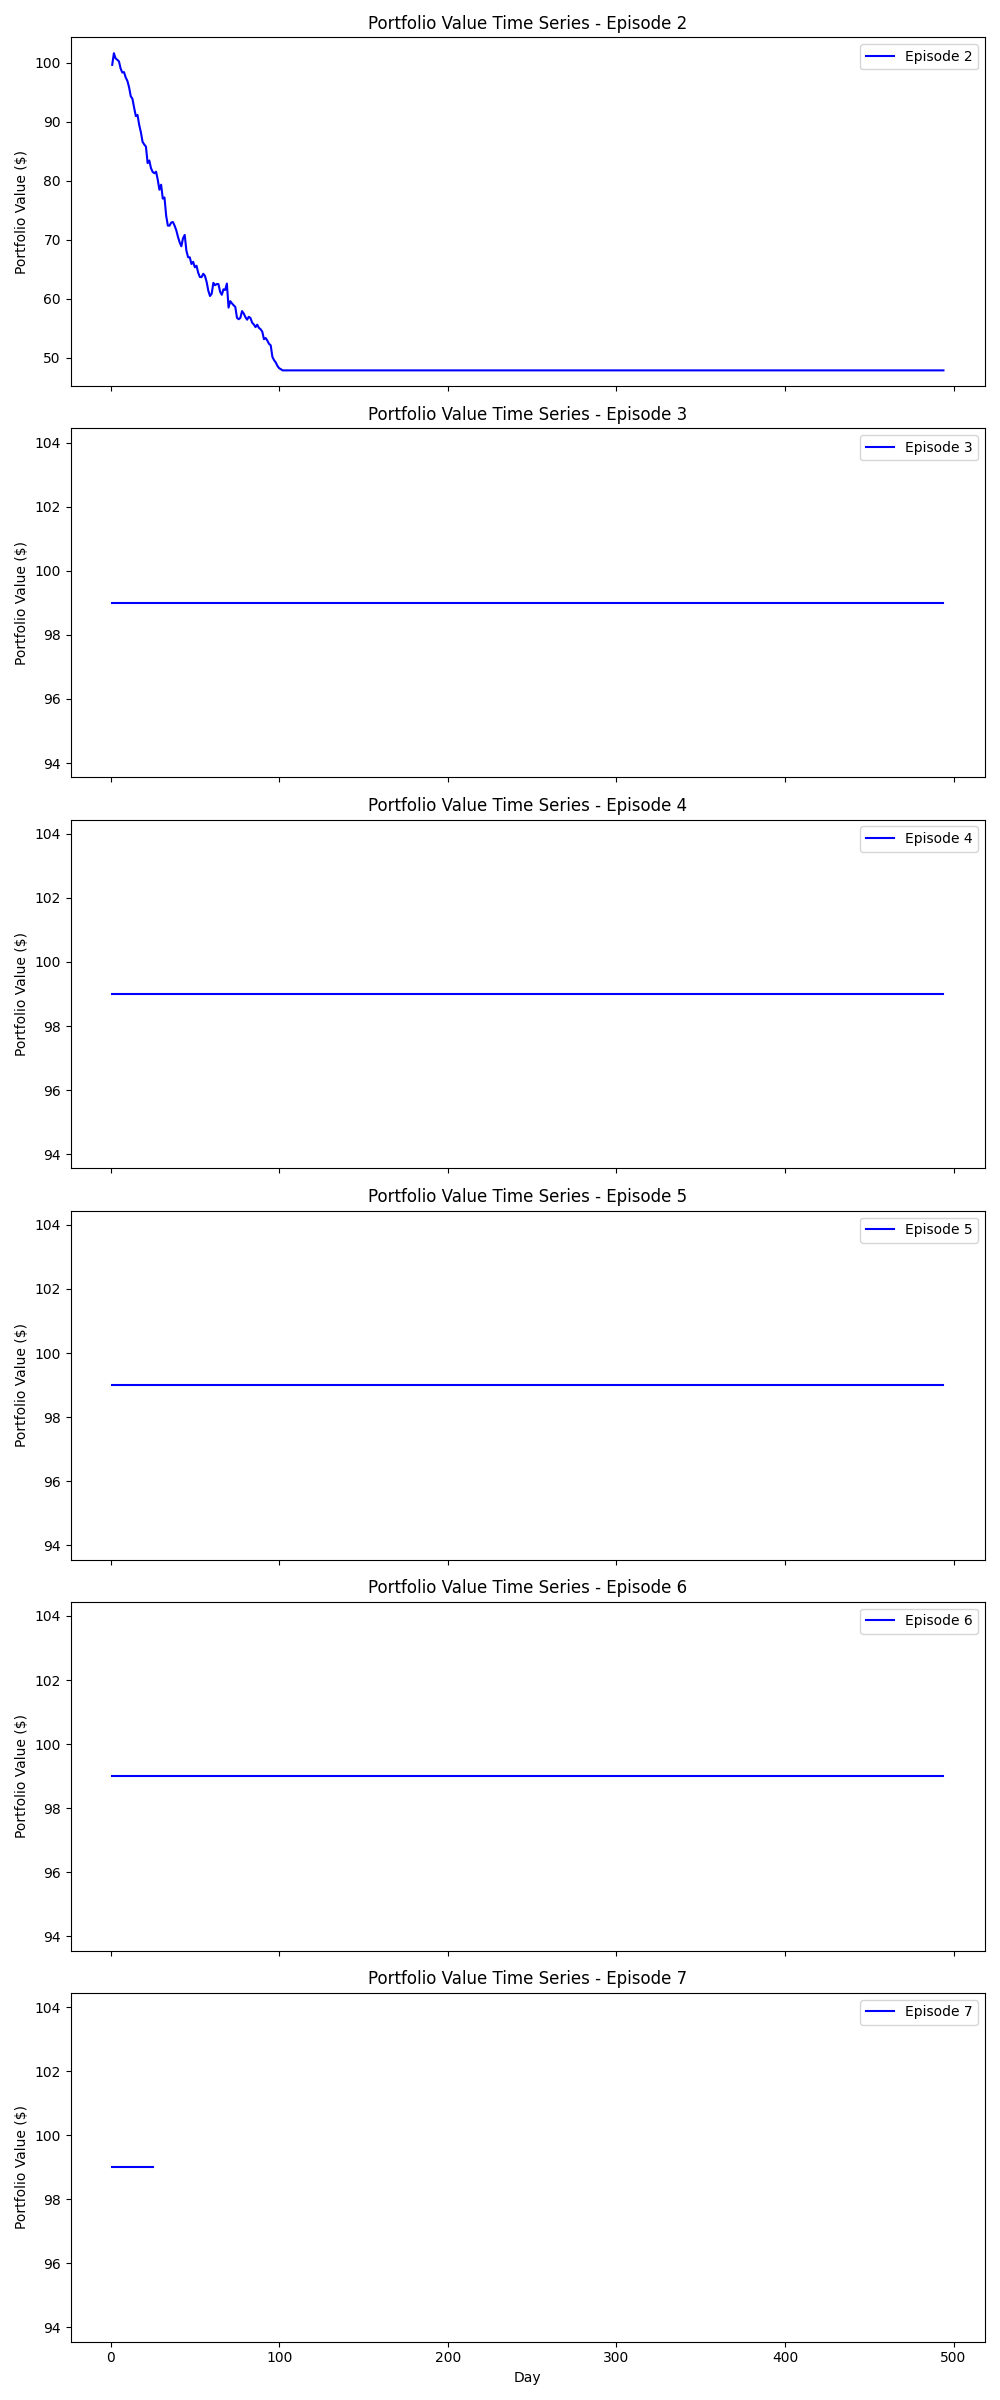

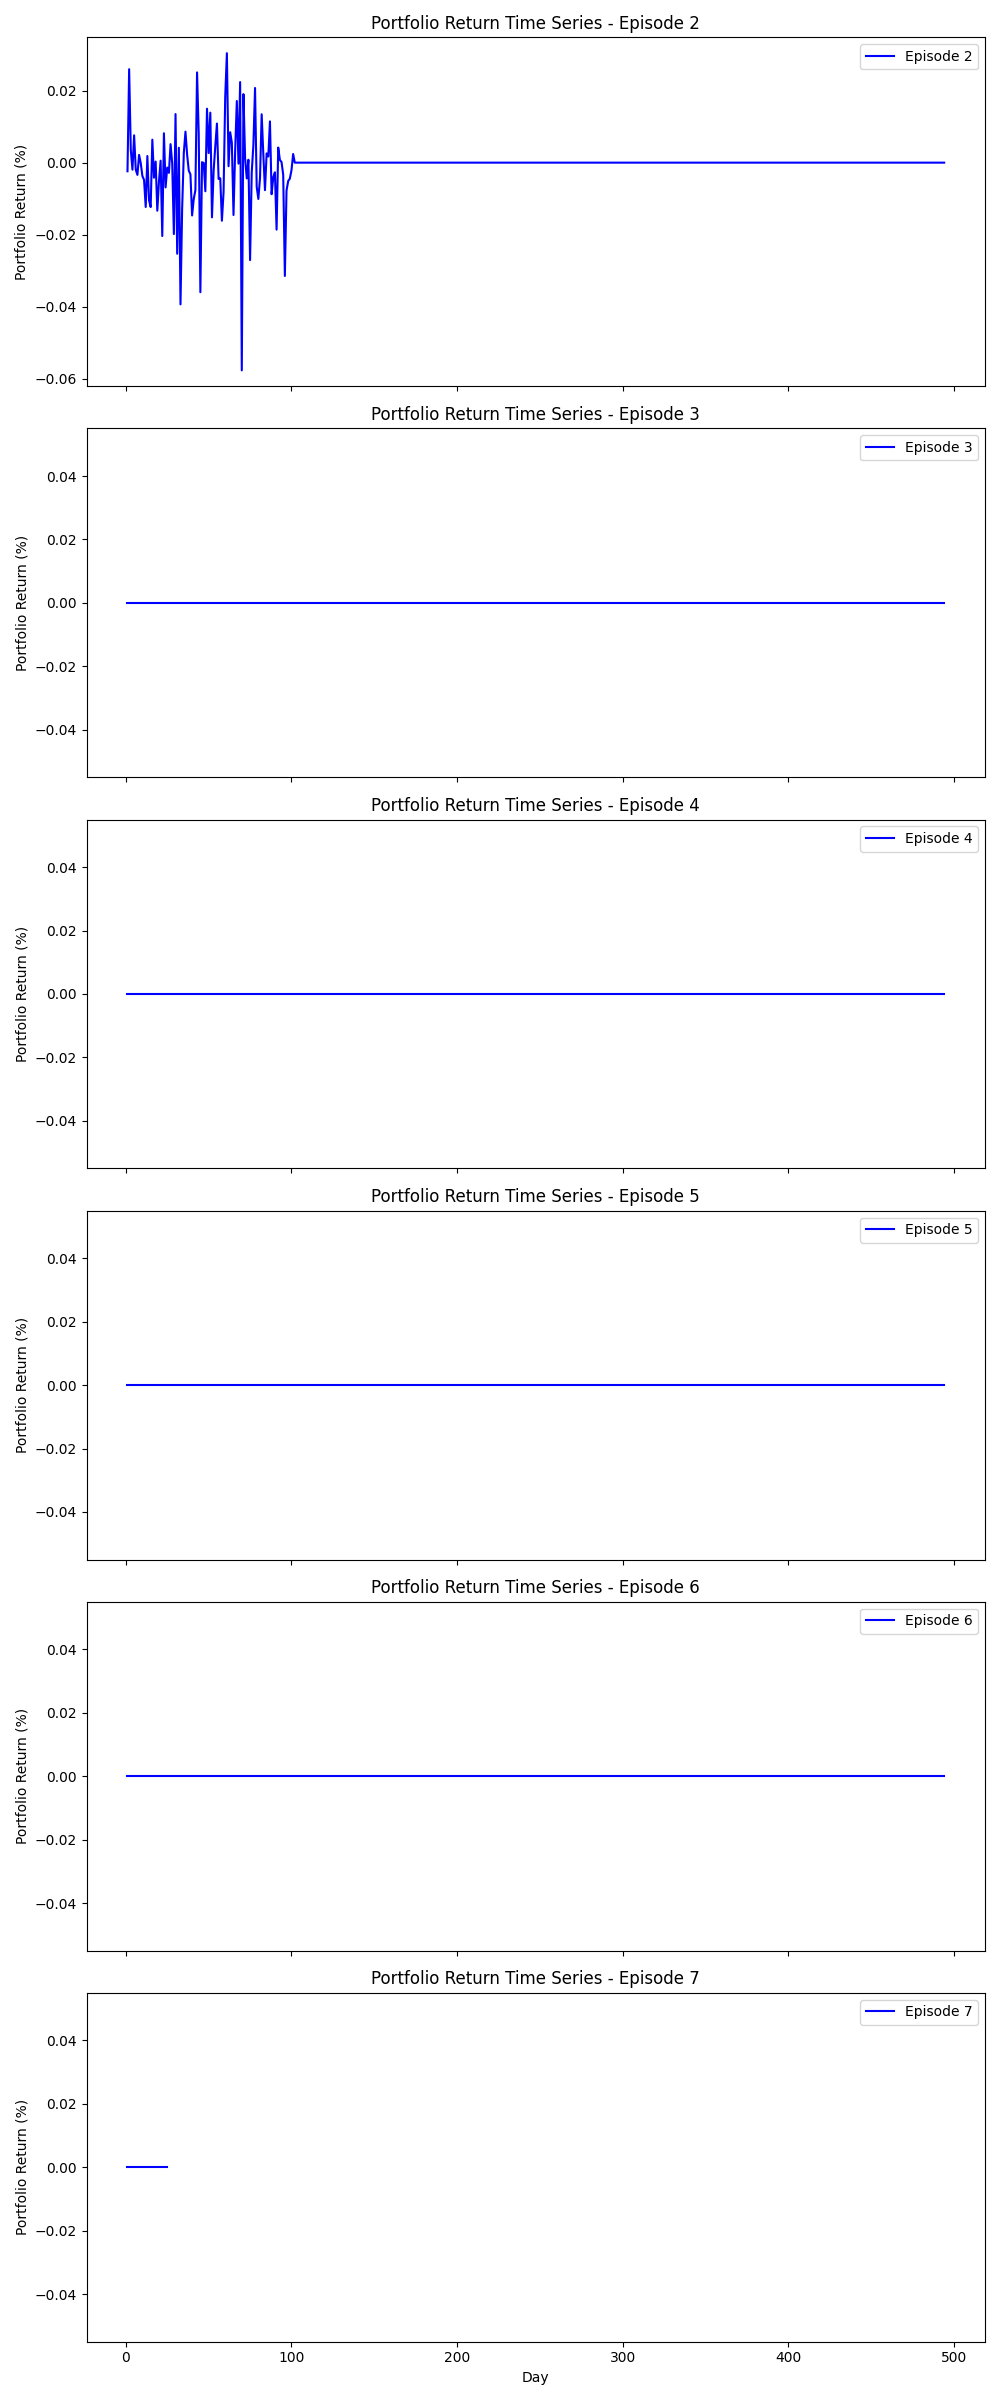

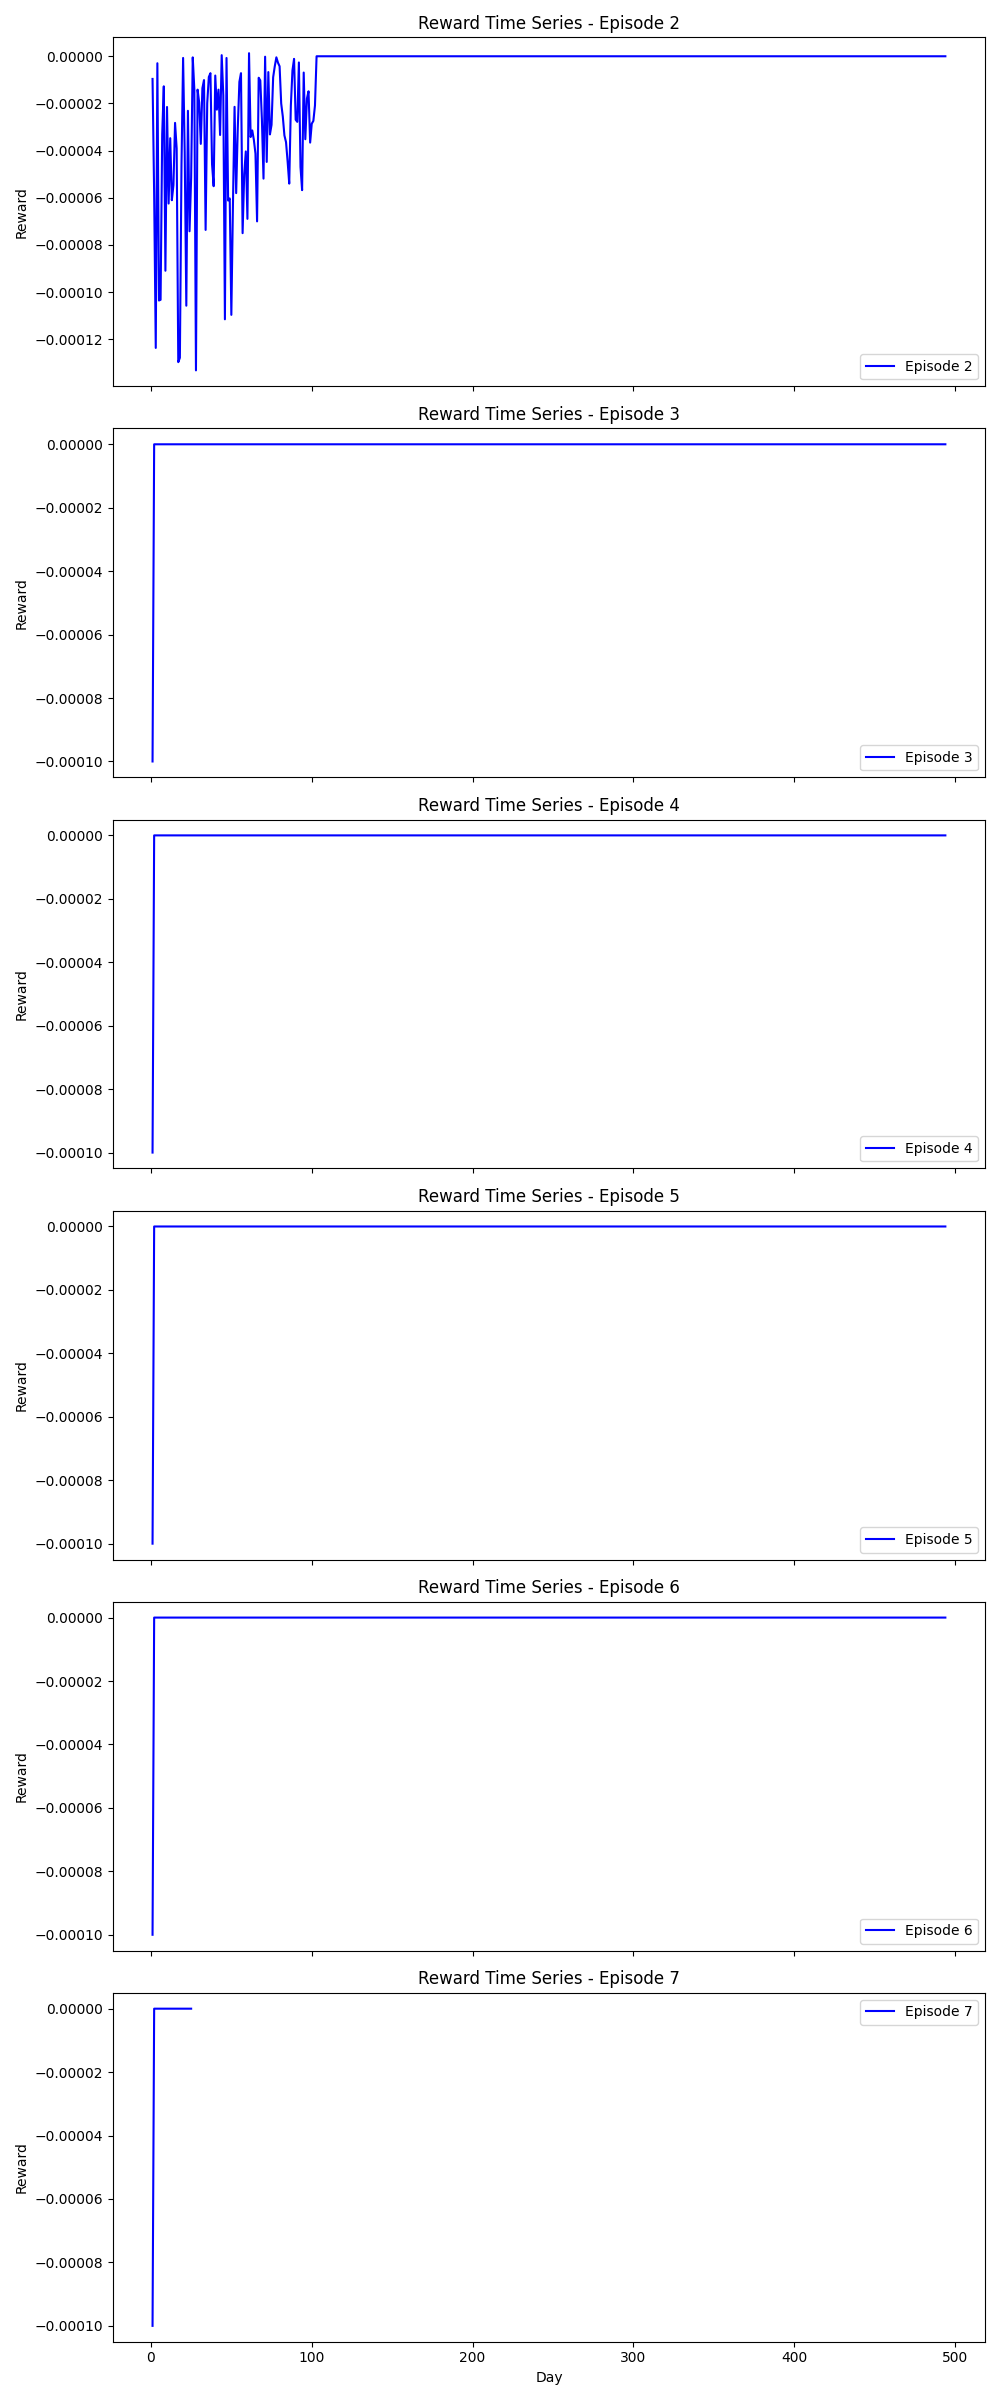

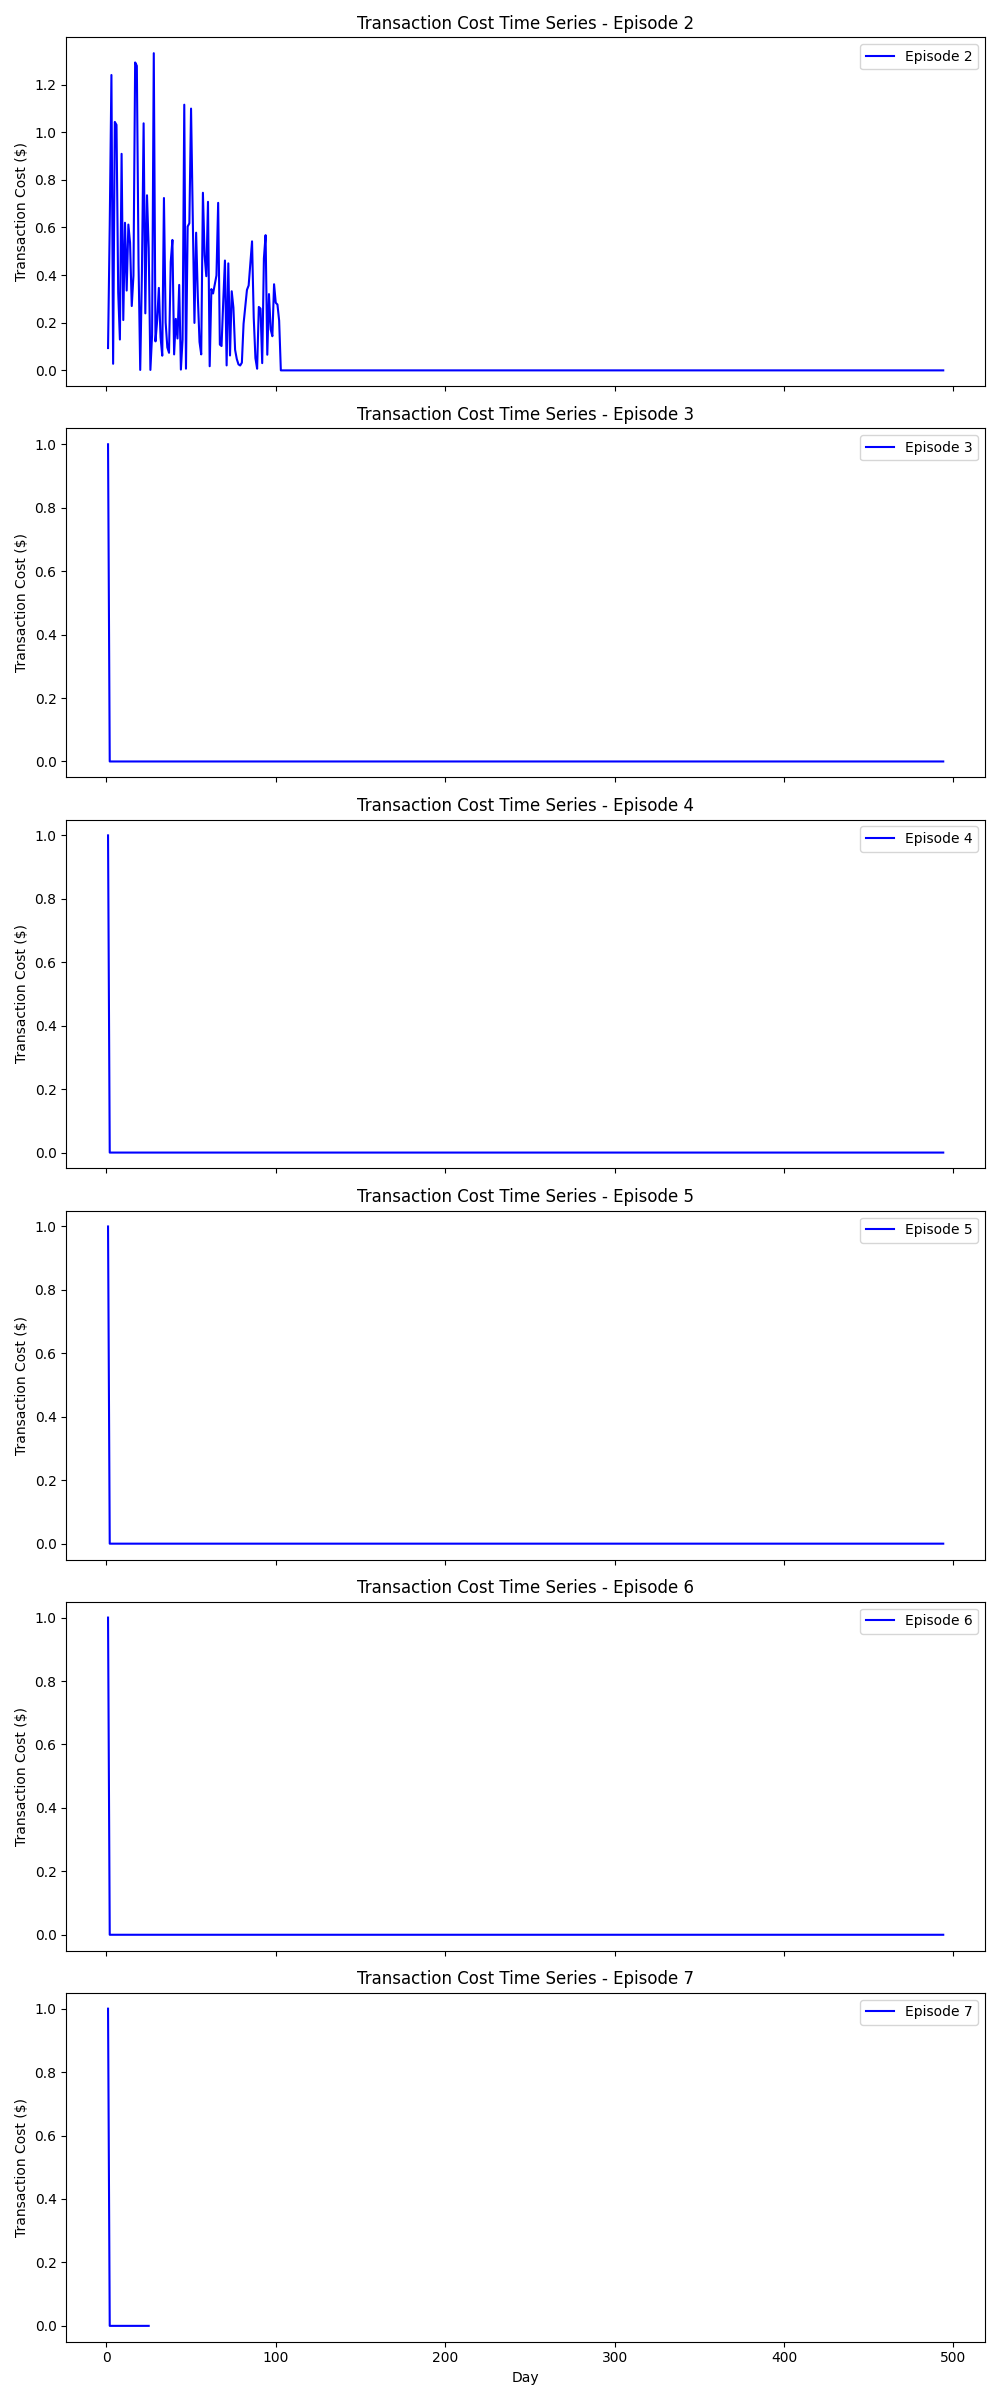

In [187]:
from IPython.display import display
from PIL import Image

display(Image.open("portfolio_value.png"))
display(Image.open("portfolio_return.png"))
display(Image.open("reward.png"))
display(Image.open("transaction_cost.png"))
